This notebook is used for testing or analyzing different things:

In [6]:
# Read the contents of the control file 'ciclos_respiratorios_train.py' with Numpy
import numpy as np

# Read the control file 'ciclos_respiratorios_train.py' with Numpy
control_file = '/app/src/data/ciclos_respiratorios_train.npy'
data = np.load(control_file, allow_pickle=True)

# Cast to pandas DataFrame
import pandas as pd

df = pd.DataFrame(data.tolist())

Now, analyze the data:

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,10,11
0,101,101_1b1_Al_sc_Meditron,0.036,0.579,0.0,0.0,Healthy,1b1,Al,sc,Meditron,0.543
1,101,101_1b1_Al_sc_Meditron,0.579,2.45,0.0,0.0,Healthy,1b1,Al,sc,Meditron,1.871
2,101,101_1b1_Al_sc_Meditron,2.45,3.893,0.0,0.0,Healthy,1b1,Al,sc,Meditron,1.443
3,101,101_1b1_Al_sc_Meditron,3.893,5.793,0.0,0.0,Healthy,1b1,Al,sc,Meditron,1.9
4,101,101_1b1_Al_sc_Meditron,5.793,7.521,0.0,0.0,Healthy,1b1,Al,sc,Meditron,1.728
...,...,...,...,...,...,...,...,...,...,...,...,...
5230,226,226_1b1_Pl_sc_LittC2SE,11.721,13.693,1.0,0.0,Crackle,1b1,Pl,sc,LittC2SE,1.972
5231,226,226_1b1_Pl_sc_LittC2SE,13.693,15.536,0.0,0.0,Healthy,1b1,Pl,sc,LittC2SE,1.843
5232,226,226_1b1_Pl_sc_LittC2SE,15.536,17.493,0.0,0.0,Healthy,1b1,Pl,sc,LittC2SE,1.957
5233,226,226_1b1_Pl_sc_LittC2SE,17.493,19.436,1.0,0.0,Crackle,1b1,Pl,sc,LittC2SE,1.943


# **Comprobación de filtro Butterworth**
En primer lugar, quiero comprobar cuál es el impacto del filtro de Butterworth:

Audio Signal Statistics: {'mean': -2.7059126e-05, 'std': 0.06038168, 'max': 0.41473728, 'min': -0.20010743, 'rms': 0.06038169}
Filtered Audio Signal Statistics: {'mean': 4.675872497776317e-06, 'std': 0.023558553833915773, 'max': 0.21022594743708276, 'min': -0.1506383837010895, 'rms': 0.023558554297946455}


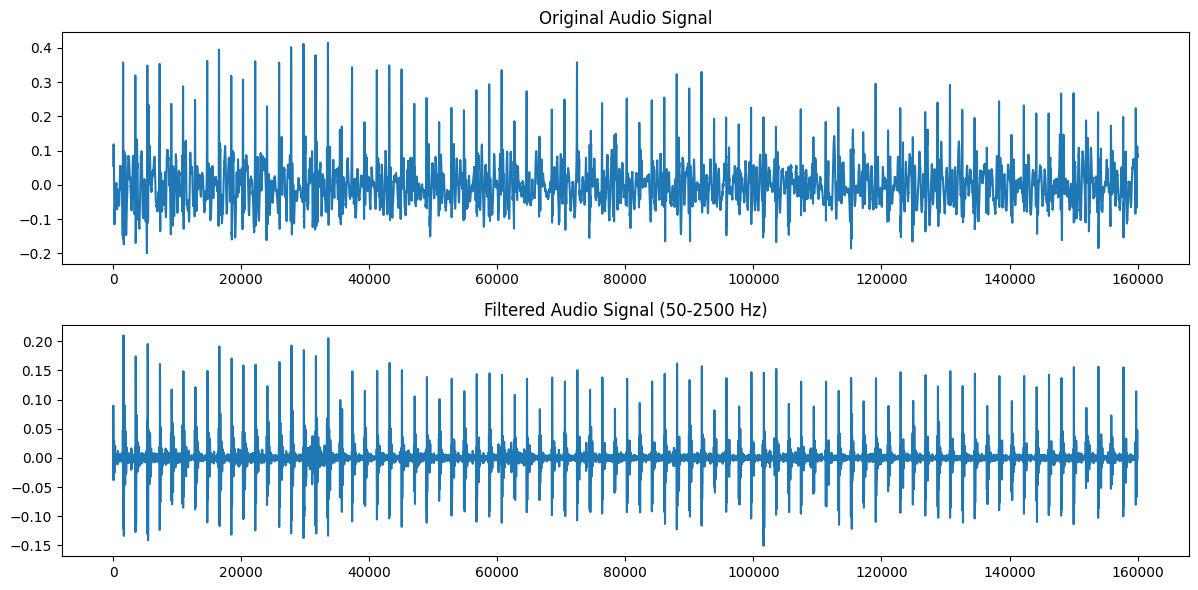

In [2]:
import librosa, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.signal import butter, lfilter

def compute_stats(signal):
    return {"mean": np.mean(signal), "std": np.std(signal), "max": np.max(signal), "min": np.min(signal), "rms": np.sqrt(np.mean(signal**2))}

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a
 
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

# Read a random audio signal from the DataFrame and compute its statistics
audio, sr = librosa.load('/app/data/raw/101_1b1_Al_sc_Meditron.wav', sr=8000)

# Compute statistics for the audio signal
stats_original = compute_stats(audio)
print("Audio Signal Statistics:", stats_original)

# Now, apply the Butterworth bandpass filter to the audio signal
filtered_audio = butter_bandpass_filter(audio, lowcut=50, highcut=2500, fs=8000, order=5)

# Compute statistics for the filtered audio signal
stats_filtered = compute_stats(filtered_audio)
print("Filtered Audio Signal Statistics:", stats_filtered)

# Finally, show the original and filtered audio signals waveforms
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(audio)
plt.title('Original Audio Signal')
plt.subplot(2, 1, 2)
plt.plot(filtered_audio)
plt.title('Filtered Audio Signal (50-2500 Hz)')
plt.tight_layout()
plt.show()

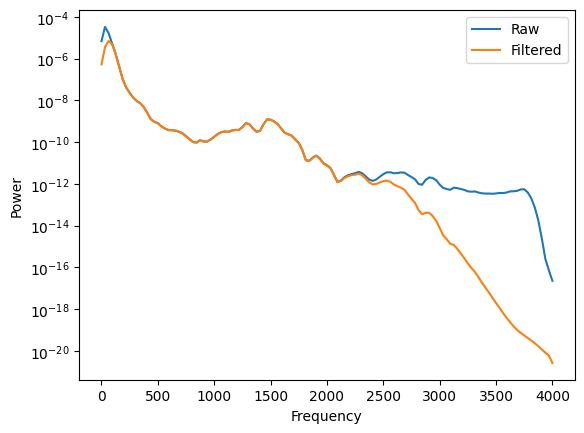

In [3]:
from scipy.signal import welch

f_raw, Pxx_raw = welch(audio, sr)
f_proc, Pxx_proc = welch(filtered_audio, sr)

plt.semilogy(f_raw, Pxx_raw, label='Raw')
plt.semilogy(f_proc, Pxx_proc, label='Filtered')
plt.legend()
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.show()

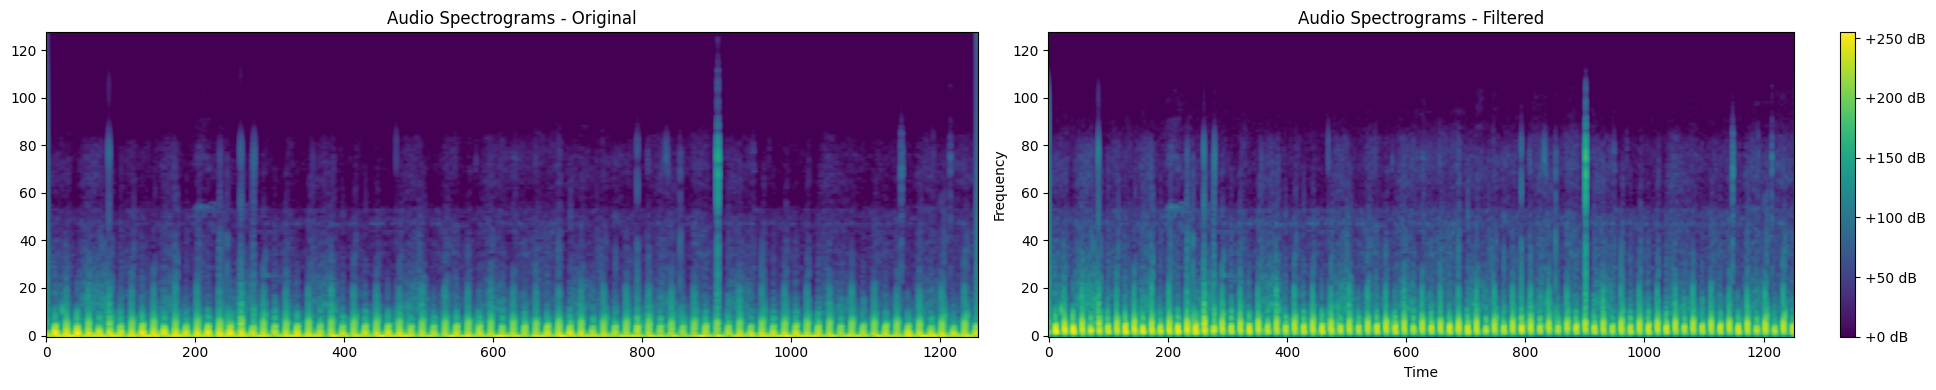

In [5]:
import cv2

def get_spectrogram(signal, sr):
    # Generate the Mel Spectrogram for the audio segment:
    spectrogram = librosa.feature.melspectrogram(y = signal, sr=sr, n_fft=2048, hop_length=128, n_mels=128)
    spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
    mean = np.mean(spectrogram)
    std = np.std(spectrogram) + 1e-6
    spectrogram = (spectrogram - mean) / std
    spectrogram = np.expand_dims(spectrogram, axis=-1)
    img = cv2.normalize(spectrogram, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if img.ndim == 3 and img.shape[-1] == 1: img = img.squeeze(-1)
    return img

def plot_spectrogram(original_audio, filtered_audio, sr, title):
    img1 = get_spectrogram(original_audio, sr)
    img2 = get_spectrogram(filtered_audio, sr)
    plt.figure(figsize=(20, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img1, aspect='auto', origin='lower', cmap='viridis')
    plt.title(f'{title} - Original')
    plt.subplot(1, 2, 2)
    plt.imshow(img2, aspect='auto', origin='lower', cmap='viridis')
    plt.title(f'{title} - Filtered')
    plt.colorbar(format='%+2.0f dB')
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

plot_spectrogram(audio, filtered_audio, sr, "Audio Spectrograms")

# **Aplicación de aumento de datos**
Tras comprobar el filtro de Butterworth, quiero analizar el impacto de las técnicas de aumento de datos:

Original Audio Statistics: {'mean': -2.7059126e-05, 'std': 0.06038168, 'max': 0.41473728, 'min': -0.20010743, 'rms': 0.06038169}
Augmented Audio 1 Statistics: {'mean': -2.6687003e-05, 'std': 0.060381748, 'max': 0.41473666, 'min': -0.20010743, 'rms': 0.060381755}
Shape of Augmented Audio 1: (160000,), Data Type: float32
Augmented Audio 2 Statistics: {'mean': -2.2494745e-05, 'std': 0.057348236, 'max': 0.41156274, 'min': -0.20010743, 'rms': 0.057348236}
Shape of Augmented Audio 2: (160000,), Data Type: float32
Augmented Audio 3 Statistics: {'mean': 6.42509e-05, 'std': 0.056361794, 'max': 0.41473728, 'min': -0.20010743, 'rms': 0.056361835}
Shape of Augmented Audio 3: (160000,), Data Type: float32


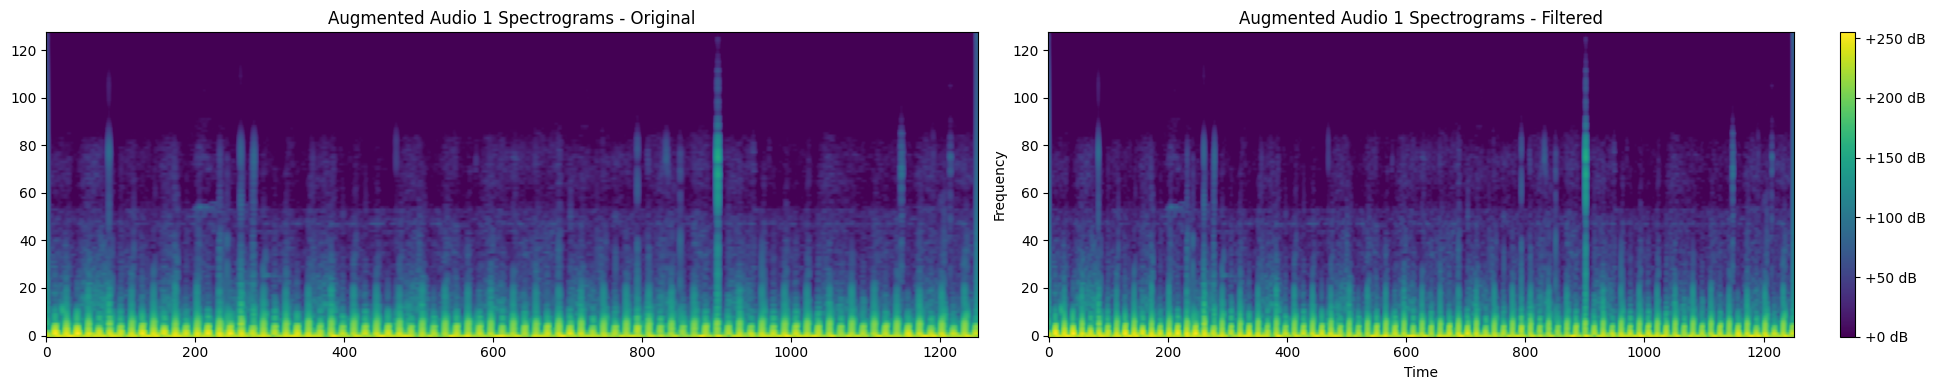

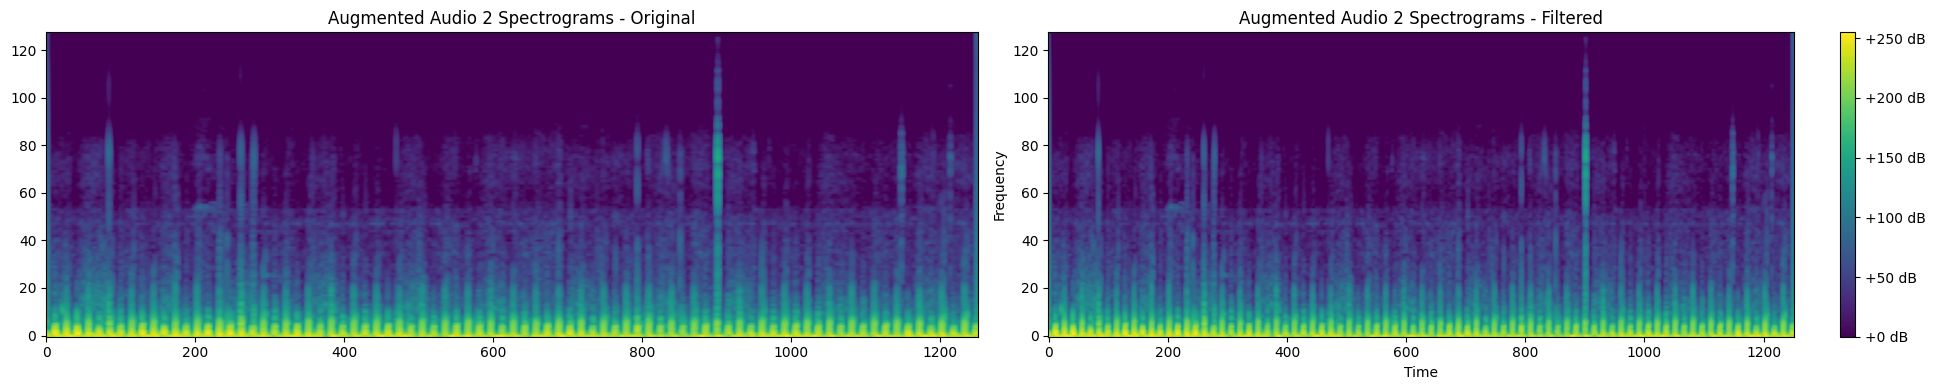

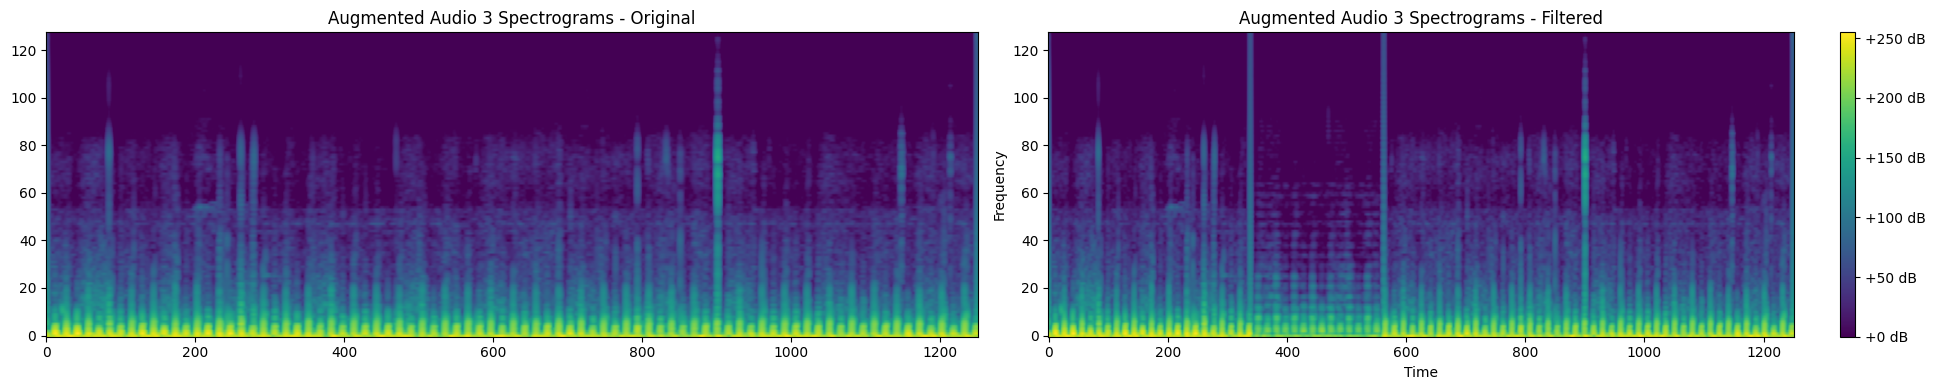

In [19]:
import nlpaug.augmenter.audio as naa

def gen_augmented(original, sample_rate):
    augment_list = [naa.NoiseAug(zone=(0.0, 1.0), coverage=0.3, color='pink'), naa.LoudnessAug(factor=(0.8, 1.2)), naa.VtlpAug(sampling_rate = sample_rate, zone=(0.2, 0.8), coverage=0.3)]
    augmented_audio_list = []
    for tecnica in augment_list:
        augmented = np.array(tecnica.augment(original))
        augmented = np.squeeze(augmented)
        if len(augmented) != len(original):
            if len(augmented) > len(original):
                augmented = augmented[:len(original)]
            else:
                augmented = np.pad(augmented, (0, len(original) - len(augmented)))
        augmented_audio_list.append(augmented)
    return augmented_audio_list

# Example usage:
audio, sr = librosa.load('/app/data/raw/101_1b1_Al_sc_Meditron.wav', sr=8000)
augmented_audios = gen_augmented(audio, sr)

print(f"Original Audio Statistics: {compute_stats(audio)}")

# Compute statistics for the augmented audio signals
for i, augmented in enumerate(augmented_audios):
    stats_augmented = compute_stats(augmented)
    print(f"Augmented Audio {i+1} Statistics:", stats_augmented)
    print(f"Shape of Augmented Audio {i+1}: {augmented.shape}, Data Type: {augmented.dtype}")

# Plot spectrograms for the original and augmented audio signals
for i, augmented in enumerate(augmented_audios):
    plot_spectrogram(audio, np.array(augmented), sr, f"Augmented Audio {i+1} Spectrograms")

In [33]:
import numpy as np
import librosa
import nlpaug.augmenter.audio as naa

def apply_augmentation(original, sample_rate, aug_type):
    augmented = original.copy()

    if aug_type == "time_shift":
        shift = np.random.randint(len(augmented))
        augmented = np.roll(augmented, shift)

    elif aug_type == "time_stretch":
        rate = np.random.uniform(0.97, 1.03)
        augmented = librosa.effects.time_stretch(augmented, rate=rate)

    elif aug_type == "vtlp":
        vtlp = naa.VtlpAug(sampling_rate=sample_rate, zone=(0.4, 0.6), coverage=0.1)
        augmented = vtlp.augment(augmented)
        augmented = np.array(augmented).squeeze()

    elif aug_type == "noise":
        noise = np.random.normal(0, 0.0005, len(augmented))
        augmented = augmented + noise

    # Ajustar longitud
    if len(augmented) != len(original):
        if len(augmented) > len(original):
            augmented = augmented[:len(original)]
        else:
            augmented = np.pad(augmented, (0, len(original) - len(augmented)))

    return augmented.astype(np.float32)

# Generate multiple augmented versions of the original audio signal
audio, sr = librosa.load('/app/data/raw/101_1b1_Al_sc_Meditron.wav', sr=8000)

# Generate multiple augmented versions of the original audio signal
augmented_audios = [apply_augmentation(audio, sr, aug_type) for aug_type in ["time_shift", "time_stretch", "vtlp", "noise"]]

print(f"Original Audio Statistics: {compute_stats(audio)}")

augmentations = ["time_shift", "time_stretch", "vtlp", "noise"]

for aug in augmentations:
    augmented = apply_augmentation(audio, sr, aug)
    
    print(f"\n=== {aug.upper()} ===")
    print("Stats:", compute_stats(augmented))
    
    # plot_spectrogram(audio, augmented, sr, f"{aug} Augmentation")

Original Audio Statistics: {'mean': -2.7059126e-05, 'std': 0.06038168, 'max': 0.41473728, 'min': -0.20010743, 'rms': 0.06038169}

=== TIME_SHIFT ===
Stats: {'mean': -2.7059197e-05, 'std': 0.060381684, 'max': 0.41473728, 'min': -0.20010743, 'rms': 0.06038169}

=== TIME_STRETCH ===
Stats: {'mean': -0.00016226953, 'std': 0.048406783, 'max': 0.36765525, 'min': -0.1958589, 'rms': 0.04840705}

=== VTLP ===
Stats: {'mean': -6.63147e-05, 'std': 0.059773266, 'max': 0.41473728, 'min': -0.20010743, 'rms': 0.0597733}

=== NOISE ===
Stats: {'mean': -2.7540267e-05, 'std': 0.060384013, 'max': 0.41462138, 'min': -0.2009498, 'rms': 0.06038402}


# **Procesamiento de Resultados**
Tras iterar diferentes conjuntos de datos, voy a analizar los resultados para establecer cuáles son las mejores semillas:

In [4]:
import os

def get_training_results(log_dir = '/app/src/testing/Semilla EfficientNet Focal Loss'):
    # This function will read every log from the directory 'app/src/testing' and obtain its best ICBHI Score:
    results = []

    # Iter over all files in the log directory
    for filename in os.listdir(log_dir):
        # We need to get the last line of the log file that contains the ICBHI Score, which is in the format: "Best ICBHI Score during training: 0.61279"
        with open(os.path.join(log_dir, filename), 'r') as f:
            lines = f.readlines()
            for line in reversed(lines):
                if "Best ICBHI Score during training:" in line:
                    best_score = float(line.split(":")[-1].strip())
                    results.append((filename, best_score))
                    break
    return results

def print_training_results(results):
    # Sort results by score in descending order
    resultados = sorted(results, key=lambda x: x[1], reverse=True)

    # # Print the ordered results
    # for filename, score in resultados:
    print(f"{resultados[0][0].split('_')[0]}: {resultados[0][1]:.5f}")
        # print(f"{filename.split('_')[0]}: {score:.5f}")

Exec the function:

In [5]:
print("Best Dataset with EfficientNet and Categorical Crossentropy:")
resultados = get_training_results('/app/src/testing/Semilla Dataset')
print_training_results(resultados)

print("\nEfficientNet with Focal Loss:")
resultados = get_training_results('/app/src/testing/Semilla EfficientNet Focal Loss')
print_training_results(resultados)

print("\nCNN with Focal Loss:")
resultados = get_training_results('/app/src/testing/Semilla CNN Focal Loss')
print_training_results(resultados)

print("\nEfficientNet with Categorical Crossentropy:")
resultados = get_training_results('/app/src/testing/Semilla EfficientNet')
print_training_results(resultados)

print("\nCNN with Categorical Crossentropy:")
resultados = get_training_results('/app/src/testing/Semilla CNN')
print_training_results(resultados)

Best Dataset with EfficientNet and Categorical Crossentropy:
seed20260119: 0.65546

EfficientNet with Focal Loss:
seed12345: 0.68163

CNN with Focal Loss:
seed1234: 0.66647

EfficientNet with Categorical Crossentropy:
seed12345678: 0.67273

CNN with Categorical Crossentropy:
seed12345678901: 0.65665


In [2]:
resultados = get_training_results('/app/src/testing/Semilla EfficientNet Focal Loss 7s')
print_training_results(resultados)

seed123456789: 0.66659
seed12345678: 0.66636
seed1234: 0.66481
seed1234567890123: 0.66434
seed123456789012: 0.66093
seed1234567: 0.66056
seed123: 0.65837
seed12345678901: 0.65342
seed123456789012345: 0.65163
seed12345678901234: 0.64523
seed1234567890: 0.64231
seed12345: 0.63830
seed123456: 0.61697
